In [1]:
import pandas as pd
import cnsplots as cns
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.image as mpimg
import cairosvg
import tempfile
import numpy as np
import seaborn as sns
from pathlib import Path
from matplotlib.colors import to_rgb, to_hex
from collections import defaultdict
import os
from openTSNE import TSNE
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from dna_features_viewer import GraphicFeature, GraphicRecord
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import tol_colors as tc

In [14]:
# define constants
COLNAME = "assigned_subcat" # hierarchy level to be analyzed, from here on defined as 'subcategory'
COLNAME_MAP = "Subcategory" # respective column name in the mapping file
TOP_COLNAME = "assigned_top" # hierarchy level to serve as top-level category/mapping
TOP_COLNAME_MAP = "Top_Category" # respective column name in the mapping file
SEQ_ID = 0.95 # sequence identity threshold used for clustering (part of input data file name)
# define dataset used for t-SNE plot
DATASET = "BacVir" # "BacVir" | "PhageOnly"
COLORBLIND = True

# assertions
assert COLNAME and TOP_COLNAME in ["assigned_subcat", "assigned_cat", "assigned_top"], "Invalid column name. Must be one of 'assigned_subcat', 'assigned_cat', or 'assigned_top'."
assert COLNAME_MAP and TOP_COLNAME_MAP in ["Subcategory", "Category", "Top_Category"], "Invalid column name. Must be one of 'Subcategory', 'Category', or 'Top_Category'."
assert SEQ_ID in [0.95, 0.2], "Invalid sequence identity threshold. Must be one of 0.95, 0.2."
assert DATASET in ["BacVir", "PhageOnly"], "Invalid dataset. Must be one of 'BacVir' or 'PhageOnly'."

In [15]:
#######################
# plotting utilities 
#######################

# define colors for top-level categories
if COLORBLIND:
    topcat_colors = {
    "Assembly": '#6DA1D6',
    "Structural": '#3E79BD',
    "Host takeover": '#F4A937',
    "NA processing": '#C1A7C4',
    "Replication": '#AD7BA4',
    "Translation": '#93C7EC',
    "AMGs": '#B8D29E', #"#ffa200",
    "Lysis": '#2C925B', 
    "Anti-Defense": '#D9070D', 
    "Effectors": '#EB7121',
    "Lysogeny": '#7BB47D', #"#ff007b",
    "Unknown": '#FFFFFF'
}
else:
    topcat_colors = {
        "Assembly": "#007BFF",
        "Structural": "#1e00ff",
        "Host takeover": "#2fff00",
        "NA processing": "#00ffb7",
        "Replication":"#00d9ff",
        "Translation": "#f6ff00",
        "AMGs": "#ffbf00", #"#ffa200",
        "Lysis": "#ff0000", 
        "Anti-Defense": "#ff00dd", 
        "Effectors": "#8e01f9", 
        "Lysogeny": "#FF5A00", #"#ff007b",
        "Unknown": "#bdbdbd"
    }

# define colors for mid-level categories
cat_colors = {
    "Transcriptional regulation": "#2fff00",
    "Transcriptional inhibition": "#02d136",
    "Host resource takeover": "#39fa69",
    "Transcriptional antitermination": "#60c006",
    "Host takeover via phosphorylation": "#3ea52e", 
    "Lytic switch": "#74d216",
    "Transcription factor": "#3C6D0F",
    "Transcriptional machinery": "#0D6806",

    "Integration": "#00ffb7",
    "Excision and transcriptional regulation": "#0dd09c",
    "DNA repair": "#0D916D",
    "Recombination": "#036D51",
    "RNA modification": "#71F8D4",
    "RNA cleavage": "#37F9AF",
    "RNA sealing": "#14AC72",

    "Maintenance": "#FF5A00", #"#ff007b",

    "Protein synthesis": "#f4fa51",
    "Ribosomal protein": "#f3fb00",
    "Translation regulation": "#d0d703",
    "Ribosome biogenesis": "#a0a512",
    "Protein maturation and folding": "#FFFF00",

    "Head morphogenesis": "#4099F9",
    "Head-to-tail joining": "#74B7FE",
    "Tail assembly": "#0F559F",
    "Baseplate assembly": "#014894",
    "DNA packaging": "#0E437B",

    "Replication initiation":"#00d9ff",
    "DNA replication":"#3AAEC3",

    "Capsid": "#1e00ff",
    "DNA injection": "#1903c1",
    "Tail and Fibers": "#553ffb",
    "Baseplate": "#3c2dad",

    "Host polysaccharide degradation": "#e24141", 
    "Endolysin": "#ff0000", 
    "Spanin": "#a90202", 
    "Lysis regulation": "#7D1C1C", 

    "Anti-Restriction": "#ff00dd", 
    "Anti-TA": "#e634f6", 
    "Anti-Defense": "#df00fd",

    "Nucleotide metabolism": "#ffbf00",
    "Other AMGs": "#ff9100",

    "Virulence factors": "#af01f9", 
    "Stress response and damage protection": "#7d01f9", 
    "Membrane transport and signaling": "#a312c3", 
    "Superinfection exclusion": "#710589", 

    "Unknown": "#bdbdbd"
}


def adjust_color(color, factor=0.2, lighten=True):
    """Mix a color with white or black. The closer the value to 1, the more white/black contained"""
    r, g, b = to_rgb(color)

    if lighten:
        r = r + (1-r)*factor
        g = g + (1-g)*factor
        b = b + (1-b)*factor
    else:
        r = r * (1-factor)
        g = g * (1-factor)
        b = b * (1-factor)

    return to_hex((r, g, b))


def get_factor_range(n, min_n=2, max_n=20, min_spread=0.1, max_spread=0.5):
    """Returns factor range depending on n"""
    # normalize n to 0-1
    t = min(1, max(0, (n - min_n) / (max_n - min_n)))

    spread = min_spread + t * (max_spread - min_spread)

    base = 0.15 
    return base, base+spread


def generate_subcategory_colors(topcat_colors, cat_to_top):
    """Generate colors for subcategories based on their top-level category colors."""
    top_to_sub = defaultdict(list)
    for sub, top in cat_to_top.items():
        top_to_sub[top].append(sub)

    sub_colors = {}

    for top, subs in top_to_sub.items():
        base_color = topcat_colors.get(top, "#999999")
        n = len(subs)

        low, high = get_factor_range(n)

        if n == 1:
            factors = [0.2]
        else:
            factors = np.linspace(low, high, n)

        for i, (sub, factor) in enumerate(zip(subs, factors)):
            lighten = (i % 2 == 0) # alternate
            sub_colors[sub] = adjust_color(base_color, factor, lighten)

    return sub_colors

# lighten top-level category colors
if COLORBLIND:
    topcat_colors_adjusted = topcat_colors
else:
    topcat_colors_adjusted = {
    k: adjust_color(v, factor=0.2, lighten=True)
    for k, v in topcat_colors.items()
}

In [16]:
#######################
# Panel A: barplot
#######################

# read mapping file for keywords to sub-, mid-, and top-level categories
keywords_map = pd.read_csv("./input_data/Category_map.csv") 

# create a mapping from subcategories to top-level categories
cat_to_top = keywords_map[[COLNAME_MAP, TOP_COLNAME_MAP]].drop_duplicates().set_index(COLNAME_MAP)[TOP_COLNAME_MAP].to_dict()

def clean_df(df, colname):
    """"Helper function to clean the dataframe by replacing entries with semicolons in the specified column with 'Unknown'."""
    mask = df[colname].str.contains(";")
    df.loc[mask, colname] = "Unknown"
    return df

# read in dataframe and clean it
all_repr = pd.read_csv(f"./input_data/all_new_representatives_assigned_cat_{SEQ_ID}.tsv", sep="\t") # all representatives, including phages, bacteria, and viruses
all_repr = clean_df(all_repr, COLNAME)

# get counts of subcategories, excluding "Unknown"
data_counts = all_repr[COLNAME].value_counts()

def counts_to_df(vc):
    """Helper function to convert a value counts series to a dataframe."""
    return vc.rename("count").reset_index().rename(columns={"index": COLNAME})

# convert counts to dataframe
df_counts = counts_to_df(data_counts)

# map subcategories to top-level categories
if COLNAME != "assigned_top":
    df_counts[TOP_COLNAME] = df_counts[COLNAME].map(cat_to_top)
else: 
    df_counts[TOP_COLNAME] = df_counts[COLNAME]

# exclude Unknowns for further analysis
df_counts = df_counts[df_counts[COLNAME] != "Unknown"]

# map subcategories to top-level categories and aggregate counts
df_top_mapped = (
    df_counts.groupby(TOP_COLNAME, as_index=False)["count"]
      .sum()
      .sort_values("count", ascending=False)
)

/tmp/ipykernel_1414859/3221469020.py:18: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  all_repr = pd.read_csv(f"./input_data/all_new_representatives_assigned_cat_{SEQ_ID}.tsv", sep="\t") # all representatives, including phages, bacteria, and viruses


In [17]:
#######################
# Panel B: t-SNE plot
#######################

# Load precomputed t-SNE
tsne_data = joblib.load(f"./input_data/tsne_{DATASET}.joblib")
X_tsne = tsne_data["coords"]
tsne_ids = tsne_data["ids"]
metadata = pd.read_csv(f"./input_data/metadata_{DATASET}.tsv", sep="\t")


def get_ordering_and_rank(colname_map, top_colname_map):
    if colname_map != "Top_Category":
        cat_to_top = keywords_map[[colname_map, top_colname_map]].drop_duplicates().set_index(colname_map)[top_colname_map].to_dict()
    else:
        cat_to_top = {x: x for x in keywords_map[colname_map].drop_duplicates()}
    unique_keys = pd.unique(list(cat_to_top.values()))
    rank = {cat: i for i, cat in enumerate(unique_keys)}
    return cat_to_top, rank


def get_color_maps(labels: List[str], metadata_col: str, topcol: str, cat_to_top) -> Dict[str, str]:
    """Generate a mapping from label values to colors

    Params
    -------
    labels (List[str]): List of category labels for each sample
    metadata_col (str): Column name used for coloring, determines color mapping strategy

    Returns
    -------
    Dict[str, str]: Dictionary mapping label values to colors
    """
    if metadata_col == "assigned_top":
        topcat_colors_adjusted = {
            k: adjust_color(v, factor=0.2, lighten=True)
            for k, v in topcat_colors.items()
        }
        color_map = {label: topcat_colors_adjusted.get(label) for label in labels}
        return color_map, topcat_colors_adjusted
    
    elif metadata_col in ("assigned_subcat", "assigned_cat"):
        if topcol == "assigned_top":
            colors = generate_subcategory_colors(topcat_colors, cat_to_top)
        elif topcol == "assigned_cat":
            colors = generate_subcategory_colors(cat_colors, cat_to_top)
        color_map = {label: colors.get(label) for label in labels}
        return color_map, colors


# Get dictionary mapping 
mapping, rank = get_ordering_and_rank(COLNAME_MAP, TOP_COLNAME_MAP)
metadata_df = metadata.copy()
metadata_df[COLNAME] = metadata_df[COLNAME].map(mapping)
dict_map, rank = get_ordering_and_rank(TOP_COLNAME_MAP, TOP_COLNAME_MAP)
labels = metadata_df[COLNAME].astype(str).values
    
unique_values = np.unique(labels)
if "Unknown" in unique_values:
    unique_values = ["Unknown"] + [v for v in unique_values if v != "Unknown"]

color_map, source_palette = get_color_maps(labels, "assigned_top", "assigned_top", dict_map)

products = metadata_df["product"].astype(str).values

/tmp/ipykernel_1414859/232644688.py:17: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  unique_keys = pd.unique(list(cat_to_top.values()))
/tmp/ipykernel_1414859/232644688.py:17: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  unique_keys = pd.unique(list(cat_to_top.values()))


In [18]:
#######################
# Panel C: Metrics BacVir95
#######################

metrics_95 = pd.read_csv(f"./input_data/BacVir95_metrics.csv")

metrics_95.rename(columns={"bv_test_indiv_f1": "F1", "bv_test_indiv_recall": "Recall", "bv_test_indiv_precision": "Precision"}, inplace=True)
metrics_95_long = metrics_95.melt(
    value_vars=["F1", "Recall", "Precision"],
    var_name="Metric",
    value_name="Score"
)

In [19]:
#######################
# Panel D: BASEL BacVir95
#######################
basel_95 = pd.read_csv(f"./input_data/BASEL_BacVir95_final.tsv", sep="\t")
basel_95_known = basel_95[basel_95["assigned_subcat_initial"] != "Unknown"]
print(len(basel_95_known))

# Get all subcategory labels
subcat_labels = sorted(set(basel_95_known["assigned_subcat_initial"]) | set(basel_95_known["Predicted Class"]))

# Subcategory confusion matrix
cm_subcat = confusion_matrix(basel_95_known["assigned_subcat_initial"], basel_95_known["Predicted Class"], labels=subcat_labels)

top_labels = list(df_top_mapped["assigned_top"].unique())

cm_top = np.zeros((len(top_labels), len(top_labels)), dtype=int)

for i, true_subcat in enumerate(subcat_labels):
    true_top = cat_to_top[true_subcat]
    true_top_idx = top_labels.index(true_top)

    for j, pred_subcat in enumerate(subcat_labels):
        pred_top = cat_to_top[pred_subcat]
        pred_top_idx = top_labels.index(pred_top)

        cm_top[true_top_idx, pred_top_idx] += cm_subcat[i, j]


cm_norm = np.divide(cm_top, cm_top.sum(axis=1, keepdims=True),
    out=np.zeros_like(cm_top, dtype=float), where=cm_top.sum(axis=1, keepdims=True) != 0)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=top_labels)

4713


In [20]:
#######################
# Panel F: Metrics BacVir20
#######################
metrics_20 = pd.read_csv(f"./input_data/BacVir20_metrics.csv")

metrics_20.rename(columns={"bv_test_indiv_f1": "F1", "bv_test_indiv_recall": "Recall", "bv_test_indiv_precision": "Precision"}, inplace=True)
metrics_20_long = metrics_20.melt(
    value_vars=["F1", "Recall", "Precision"],
    var_name="Metric",
    value_name="Score"
)

In [21]:
#######################
# Panel G: BASEL BacVir20
#######################

basel_20 = pd.read_csv(f"./input_data/BASEL_BacVir20_final.tsv", sep="\t")
basel_20 = basel_20[basel_20["assigned_subcat_initial"] != "Unknown"]


# Get all subcategory labels
subcat_labels20 = sorted(set(basel_20["assigned_subcat_initial"]) | set(basel_20["Predicted Class"]))

# Subcategory confusion matrix
cm_subcat20 = confusion_matrix(basel_20["assigned_subcat_initial"], basel_20["Predicted Class"], labels=subcat_labels20)

cm_top20 = np.zeros((len(top_labels), len(top_labels)), dtype=int)

for i, true_subcat in enumerate(subcat_labels20):
    true_top = cat_to_top[true_subcat]
    true_top_idx = top_labels.index(true_top)

    for j, pred_subcat in enumerate(subcat_labels20):
        pred_top = cat_to_top[pred_subcat]
        pred_top_idx = top_labels.index(pred_top)

        cm_top20[true_top_idx, pred_top_idx] += cm_subcat20[i, j]


cm_norm20 = np.divide(cm_top20, cm_top20.sum(axis=1, keepdims=True),
    out=np.zeros_like(cm_top20, dtype=float), where=cm_top20.sum(axis=1, keepdims=True) != 0)

disp20 = ConfusionMatrixDisplay(confusion_matrix=cm_norm20, display_labels=top_labels)

In [22]:
#######################
# Panel H: Comparison Pharokka-Phold (all proteins)
#######################
preds_pharokka_phold = pd.read_csv("./input_data/Preds_BacVir95_Pharokka_Phold.tsv", sep="\t")

N = len(preds_pharokka_phold)
thresholds = np.linspace(0, 1, 101)
confidence_metric = "score_weighted"
conf = preds_pharokka_phold[confidence_metric].fillna(0)

# classifier
annotation_rates = []

for t in thresholds:
    subset = preds_pharokka_phold[preds_pharokka_phold["P(Predicted)"] >= t]
    annotation_rates.append(len(subset) / N)

classifier_rate = pd.DataFrame({
    "Threshold": thresholds,
    "Annotation Rate": annotation_rates
})

# Pharokka only
pharokka_only = preds_pharokka_phold.loc[
    (preds_pharokka_phold["assigned_subcat_pharokka"] != "Unknown") &
    (preds_pharokka_phold["assigned_subcat_pharokka"] != "Other")
]

pharokka_rate = len(set(pharokka_only["protein_ID"])) / N

# Pharokka-Phold
annotation_rates_pharokka_and_phold = []

for t in thresholds:
    phold_ids = set(preds_pharokka_phold.loc[(conf >= t) &
        (preds_pharokka_phold["assigned_subcat_phold"] != "Unknown") & (preds_pharokka_phold["assigned_subcat_phold"] != "Other")
                                  , "protein_ID"])

    pharokka_ids = set(
        preds_pharokka_phold.loc[
            (preds_pharokka_phold["assigned_subcat_pharokka"] != "Unknown") &
            (preds_pharokka_phold["assigned_subcat_pharokka"] != "Other"),
            "protein_ID"
        ]
    )

    union_ids = phold_ids | pharokka_ids
    annotation_rates_pharokka_and_phold.append(len(union_ids) / N)

pharokka_phold_rate = pd.DataFrame({
    "Threshold": thresholds,
    "Annotation Rate": annotation_rates_pharokka_and_phold
})

/tmp/ipykernel_1414859/3667272327.py:4: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  preds_pharokka_phold = pd.read_csv("./input_data/Preds_BacVir95_Pharokka_Phold.tsv", sep="\t")


In [23]:
#######################
# Panel H: Comparison Pharokka-Phold (unknome)
#######################
reps95 = pd.read_csv("../cnsplots/input_data/all_new_representatives_assigned_cat_0.95.tsv", sep="\t")
reps95_phage = reps95[reps95["table_origin"] == "phg"]
print(len(reps95_phage))

def clean_df(df, colname):
    """"Helper function to clean the dataframe by replacing entries with semicolons in the specified column with 'Unknown'."""
    mask = df[colname].str.contains(";")
    df.loc[mask, colname] = "Unknown"
    return df
    
preds_pharokka_phold = clean_df(preds_pharokka_phold, "assigned_subcat_initial")
preds95 = preds_pharokka_phold[preds_pharokka_phold["protein_ID"].isin(reps95_phage["protein_ID"])]
print(len(preds95))

annotation_rates_unknowns = []
annotation_rates_phold = []
N_unknowns = len(preds95[preds95["assigned_subcat_initial"] == "Unknown"])

for t in thresholds:
    subset = preds95[preds95["P(Predicted)"] >= t]
    unknown_subset = subset[(subset["assigned_subcat_initial"] == "Unknown")]
    total_pred = len(unknown_subset)
    annotation_rates_unknowns.append(total_pred / N_unknowns)

    subset_phold = unknown_subset[conf >= t]
    subset_valid_phold = subset_phold[(subset_phold["assigned_subcat_phold"] != "Unknown") & (subset_phold["assigned_subcat_phold"] != "Other")]
    annotation_rates_phold.append(len(subset_valid_phold) / N_unknowns)

unknome_rate_classifier = pd.DataFrame({"Threshold": thresholds, "Annotation Rate": annotation_rates_unknowns})
unknome_rate_phold = pd.DataFrame({"Threshold": thresholds, "Annotation Rate": annotation_rates_phold})

/tmp/ipykernel_1414859/2269992813.py:4: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  reps95 = pd.read_csv("../cnsplots/input_data/all_new_representatives_assigned_cat_0.95.tsv", sep="\t")


233882
233882


/tmp/ipykernel_1414859/2269992813.py:28: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset_phold = unknown_subset[conf >= t]
/tmp/ipykernel_1414859/2269992813.py:28: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset_phold = unknown_subset[conf >= t]
/tmp/ipykernel_1414859/2269992813.py:28: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset_phold = unknown_subset[conf >= t]
/tmp/ipykernel_1414859/2269992813.py:28: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset_phold = unknown_subset[conf >= t]
/tmp/ipykernel_1414859/2269992813.py:28: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset_phold = unknown_subset[conf >= t]
/tmp/ipykernel_1414859/2269992813.py:28: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset_phold = unknown_subset[conf >= t]
/tmp/ipykernel_1414859/2269992813.py:28:

In [24]:
print([x for x in dir(cns) if x.isupper()])

['BLUE', 'BROWN', 'CHOCOLATE', 'GRAY', 'GREEN', 'ORANGE', 'PINK', 'PURPLE', 'RED', 'TYPE_CHECKING', 'VIOLET', 'YELLOW', '_LAZY_IMPORTS']


findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

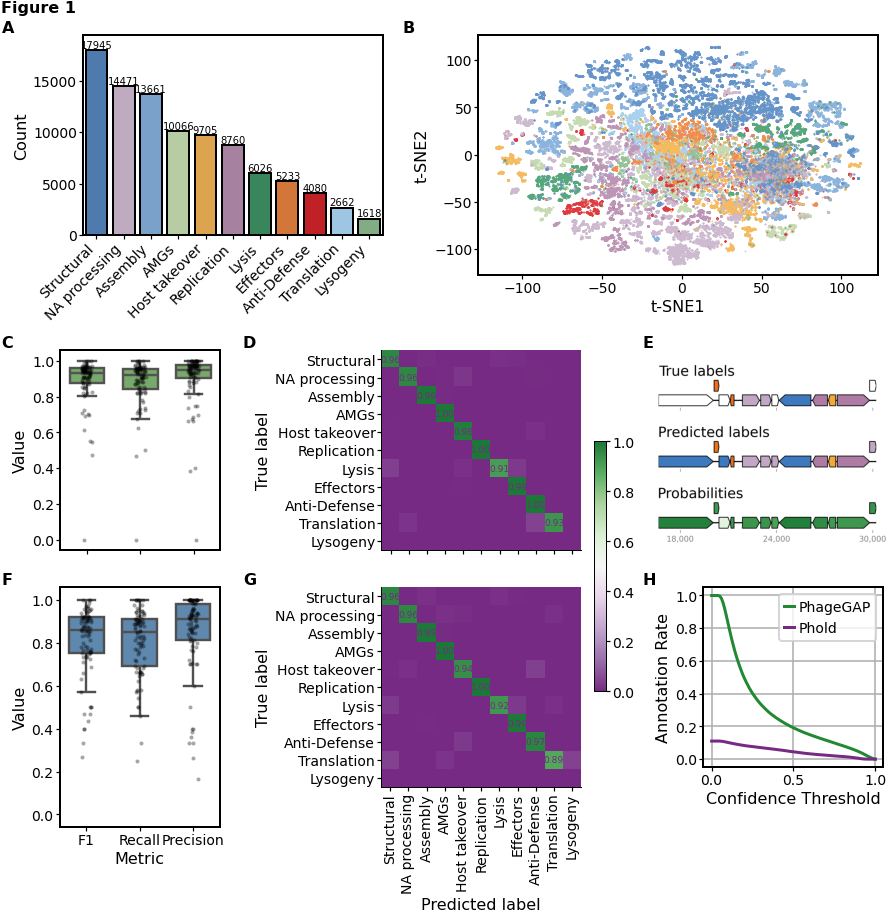

In [25]:
cns.settings.title_fontweight = "normal"
mp = cns.multipanel(
    max_width=600, title="Figure 1", title_fontweight="bold", loc="left"
)
#detached_panel_layouts = []

######################
# Panel A: boxplot
mp.panel("A", 150, 100)
ax = cns.barplot(
    data=df_top_mapped, x=TOP_COLNAME, y="count", palette=topcat_colors_adjusted, hue=TOP_COLNAME, legend=False, errorbar=None, edgecolor="black"
)
# customize axes
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Count")
plt.xlabel("")

for p in ax.patches:
    height = p.get_height()

    if height == 0:
        continue

    x = p.get_x() + p.get_width() / 2
    ax.text(x, height, f"{int(height)}", ha="center", va="bottom", fontsize=5)

ymax = df_top_mapped["count"].max()
ax.set_ylim(0, ymax * 1.08)

ax.set_title("")

######################
# Panel B: t-SNE plot
mp.panel("B", 200, 120, margin_right=10)
ax = plt.gca()

if "dataset" in metadata_df.columns:
    dataset_labels = metadata_df["dataset"].values
    for val in unique_values:
        color = color_map.get(val)

        if color is None:
            print(f"Skipping {val}: no color defined")
            continue

        label_mask = labels == val

        phage_mask = label_mask & (dataset_labels == "PhageOnly")
        ax.scatter(X_tsne[phage_mask, 0], X_tsne[phage_mask, 1], color=color, lw=0.3, alpha=0.5, s=0.5, marker="o")
        bacvir_mask = label_mask & (dataset_labels == "BacVir")
        ax.scatter(X_tsne[bacvir_mask, 0], X_tsne[bacvir_mask, 1], color=color, lw=0.3, alpha=0.5, s=0.5, marker="o")
else:
    for val in unique_values:
        mask = labels == val
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=val, color=color_map[val], lw=0.3, alpha=0.5, s=0.5)

ax.set_ylabel("t-SNE2")
ax.set_xlabel("t-SNE1")

legend = ax.get_legend()
if legend is not None:
    legend.remove()

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)


######################
# Panel C: BacVir95 recall, precision, f1-score plot
mp.panel("C", 80, 100, below="A", margin_top=40, color_cycle=[cns.GREEN])
ax = plt.gca()
sns.boxplot(data=metrics_95_long, x="Metric", y="Score",
            width=0.65, linewidth=1.2,
            fliersize=0, ax=ax)

sns.stripplot(data=metrics_95_long, x="Metric", y="Score", 
              dodge=True, color="black", alpha=0.35,
              size=2, ax=ax)

ax.set_xlabel("")
#ax.set_xticks([])
ax.set_xticklabels([])
ax.set_ylabel("Value")
ax.set_ylim(-0.06, 1.06)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1) 

######################
# panel D: 10 BASEL phages confusion matrix (mapped to top-level)
mp.panel("D", 100, 100, below="B", margin_top=20, margin_left=-80)
ax = plt.gca()
form = ".2f"
text_fs = 4.5

# use confusion matrix display (disp) which has been instantiated earlier
disp.plot(ax=ax, 
    cmap=tc.PRGn, #cmap="RdYlGn", 
    values_format=form, im_kw={"vmin": 0, "vmax": 1}, xticks_rotation=90, text_kw={"fontsize": text_fs},
    colorbar=False)

threshold = 0.1
for text, value in zip(disp.text_.ravel(), cm_norm.ravel()):
    if value < threshold:
        text.set_text("")
#ax.set_xticks([])
ax.set_xticklabels([])
ax.set_xlabel("")
ax.set_ylabel("True label")

######################
# panel E: predicted classes for phage YY and their probabilities
mp.panel("E", 100, 100, below="B",  margin_top=-236, margin_left=120)
ax = plt.gca()
ax.set_axis_off()

if COLORBLIND:
    img1 = mpimg.imread("./plots/genomic_context_95_colorblind/0_Escherichia phage LeonhardEuler_16645_30223.png")
else:
    img1 = mpimg.imread("./plots/genomic_context_95/0_Escherichia phage LeonhardEuler_16645_30223.png")
ax1 = ax.inset_axes([-0.15, 0, 1.2, 1.0])
ax1.imshow(img1)
ax1.set_axis_off()

######################
# panel F: BacVir20 recall, precision, f1-score plot
mp.panel("F", 80, 120, below="C", margin_top=1, color_cycle=[cns.BLUE])
ax = plt.gca()
sns.boxplot(data=metrics_20_long, x="Metric", y="Score",
            width=0.65, linewidth=1.2,
            fliersize=0, ax=ax)

sns.stripplot(data=metrics_20_long, x="Metric", y="Score", 
              dodge=True, color="black", alpha=0.35,
              size=2, ax=ax)

ax.set_xlabel("Metric")
ax.set_ylabel("Value")
ax.set_ylim(-0.06, 1.06)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1) 

######################
# panel G: 10 BASEL phages confusion matrix (mapped to top-level) (BacVir20)
mp.panel("G", 100, 100, below="D", margin_top=1, margin_left=-80)
ax = plt.gca()
form = ".2f"
text_fs = 4.5

# use confusion matrix display (disp) which has been instantiated earlier
disp20.plot(ax=ax, 
    #cmap="RdYlGn", 
    cmap=tc.PRGn,
    values_format=form, im_kw={"vmin": 0, "vmax": 1}, xticks_rotation=90, text_kw={"fontsize": text_fs})

threshold = 0.1
for text, value in zip(disp20.text_.ravel(), cm_norm20.ravel()):
    if value < threshold:
        text.set_text("")

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

# move colorbar up
fig = ax.get_figure()
cbar_ax = fig.axes[-1]
pos = cbar_ax.get_position()
cbar_ax.set_position([pos.x0, pos.y0 + 0.12, pos.width, pos.height])


######################
# panel H: Vgl Pharokka Phold 
mp.panel("H", 90, 90, below="E", margin_top=1, margin_left=120)
ax = plt.gca()

"""
# Comparison on all proteins (also labeled ones)
ax.plot(classifier_rate["Threshold"], classifier_rate["Annotation Rate"], color="mediumorchid", label="Classifier")
ax.plot(pharokka_phold_rate["Threshold"], pharokka_phold_rate["Annotation Rate"], color="darkcyan", label="Pharokka-Phold")
ax.axhline(y=pharokka_rate, linestyle=":", linewidth=1, color="forestgreen", label="Pharokka baseline")
ax.set_ylabel("Annotation Rate")
ax.set_xlabel("Confidence Threshold")
ax.legend(frameon=True, fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.25))

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1) 
"""

# comparison on the "unknome" only
ax.plot(unknome_rate_classifier["Threshold"], unknome_rate_classifier["Annotation Rate"], label="PhageGAP", color="#228833")
ax.plot(unknome_rate_phold["Threshold"], unknome_rate_phold["Annotation Rate"], label="Phold", color="#762A83") #EE7733
ax.grid(True)
ax.set_ylabel("Annotation Rate")
ax.set_xlabel("Confidence Threshold")
ax.legend(frameon=True, fontsize=7, loc="best")

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1) 

# Save final figure
outdir = Path("./plots/")
outdir.mkdir(parents=True, exist_ok=True)
if COLORBLIND:
    cns.savefig(outdir / f"Figure1_tSNE_{DATASET}_colorblind.svg")
else:
    cns.savefig(outdir / f"Figure1_tSNE_{DATASET}.svg")